# Notebook to directly run the model trained on healthy patients on IRD patients

## Library Imports

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from retinal_seg.config import BATCH_SIZE, EPOCHS, IMG_CHANNELS, IMG_HEIGHT, IMG_WIDTH, NUM_CLASSES
from retinal_seg.data.loader import datasets_from_maps, train_val_test_split
from retinal_seg.model.losses import dice_coef, weighted_ce_dice
from retinal_seg.model.unet import build_unet

In [3]:
FIG_DIR = Path(os.getcwd()).parent / "figures" / "ird_direct_application_healthy"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR = (
    Path(os.getcwd()).parent
    / "trained_models_checkpoint"
    / "ird_direct_application_healthy"
)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## Get paths for train/ valid and test set

In [4]:
# Files are stored within this directory
directory = (
    Path(os.getcwd()).parent.parent / "diseased_1509/Segmentierung_Dicom_14.9_IRD"
)

x_path = []
y_path = []

x_y_map = {}

for file in sorted(os.listdir(directory)):
    filename = os.fsdecode(file)
    if filename.endswith(".npy") and "Final" not in filename:
        idx_x = filename.split(".npy")[0].split("_")[-1]
        x_y_map[str(directory) + "/" + filename] = (
            str(directory)
            + "/"
            + filename.split(".")[0]
            + f"_Surfaces_Retina-JEI-Final_{idx_x}.npy"
        )

In [5]:
len(x_y_map)

1225

## Get class distribution

In [6]:
# class_0, class_1, class_2, class_3 = get_class_distribution(x_y_map)
# print(class_0, class_1, class_2, class_3)

## Split training set by patient names 
#### Patient name defined as first two words seperated by "_" within file name

In [ ]:
train_x_y_map, val_x_y_map, test_x_y_map = train_val_test_split(x_y_map, val_ratio=0.1, test_ratio=0.1)

In [12]:
len(train_x_y_map)

931

## Define dataloader


In [ ]:
train_dataset, val_dataset, test_dataset = datasets_from_maps(train_x_y_map, val_x_y_map, test_x_y_map, batch_size=BATCH_SIZE)

In [ ]:
SHUFFLE_BUFFER_SIZE = 1

## Define model and directly apply to IRD

In [ ]:
model_new = build_unet(
    pretrained_weights="../trained_models_checkpoint/healthy_all_CE",
    img_width=IMG_WIDTH,
    img_height=IMG_HEIGHT,
    img_channels=IMG_CHANNELS,
    n_classes=NUM_CLASSES,
    last_activation="softmax",
    compile_model=True,
    bn_list=[True] * 14,
    drop_rate=0.0,
    non_local_attention=False,
    momentum=0.9,
    loss=weighted_ce_dice,
)

In [81]:
# model_new.save_weights(MODEL_DIR)

## Get overall test dice and ONL Dice

In [16]:
test_dataset_batch = test_dataset.batch(BATCH_SIZE)
dice_coefs_test = []
dice_coefs_test_onl = []
for test in test_dataset_batch:
    pred = model_new.predict(test[0])
    dice_coef_ = dice_coef(test[1], pred)
    dice_coefs_test.append(dice_coef_)

    dice_coef_onl = dice_coef(test[1][:, :, :, 2], pred[:, :, :, 2])
    dice_coefs_test_onl.append(dice_coef_onl)


print(np.mean(dice_coefs_test))

print(np.mean(dice_coefs_test_onl))

0.92144376
0.3175248


### Validation Dice

In [ ]:
dice_coefs_test = []
dice_coefs_test_onl = []
for test in val_dataset:
    pred = model_new.predict(test[0])
    dice_coef_ = dice_coef(test[1], pred)
    dice_coefs_test.append(dice_coef_)

    dice_coef_onl = dice_coef(test[1][:, :, :, 2], pred[:, :, :, 2])
    dice_coefs_test_onl.append(dice_coef_onl)


print(np.mean(dice_coefs_test))

print(np.mean(dice_coefs_test_onl))

0.9187901
0.1286658


## Plot results of test set

/home/ec2-user/anaconda3/envs/amazonei_tensorflow2_p36/lib/python3.6/site-packages/ipykernel/__main__.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


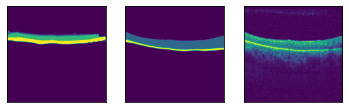

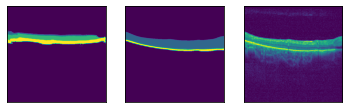

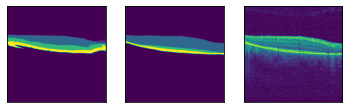

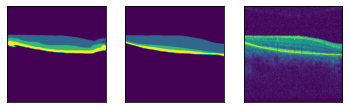

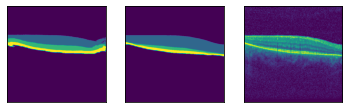

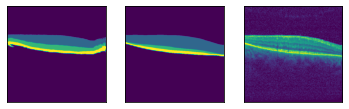

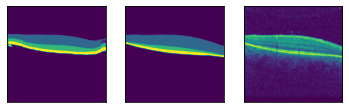

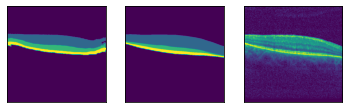

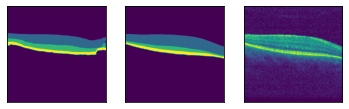

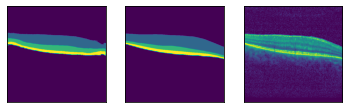

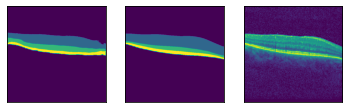

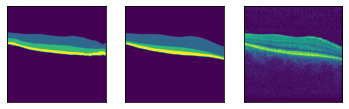

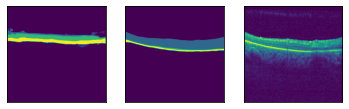

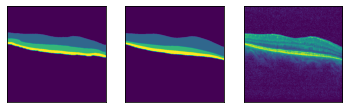

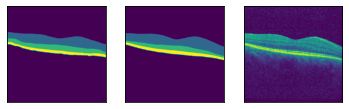

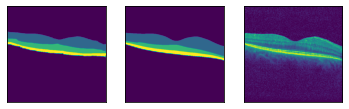

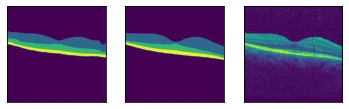

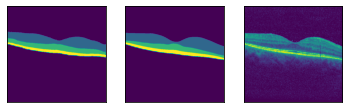

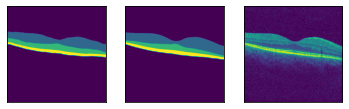

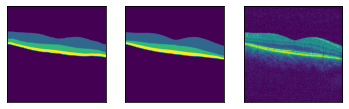

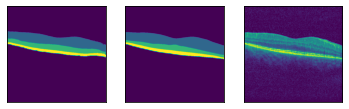

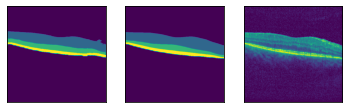

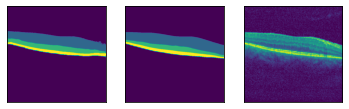

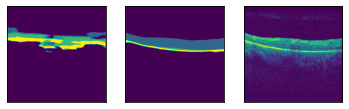

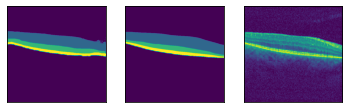

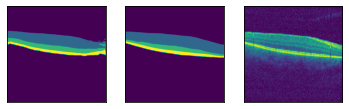

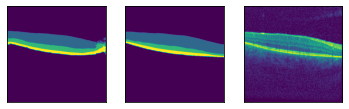

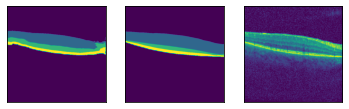

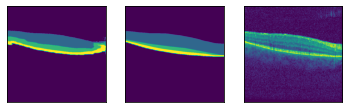

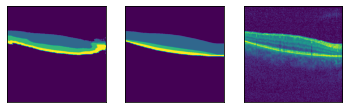

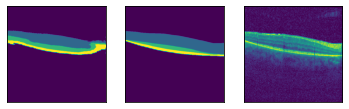

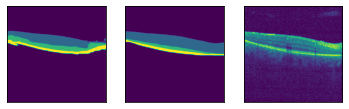

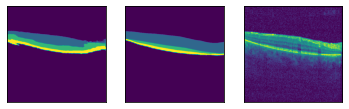

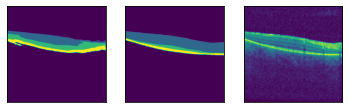

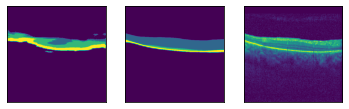

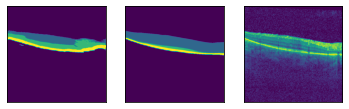

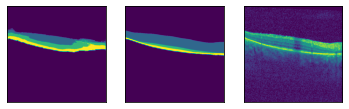

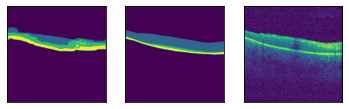

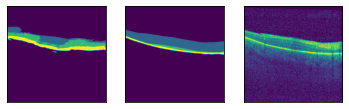

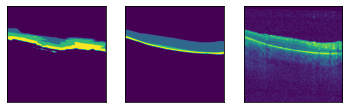

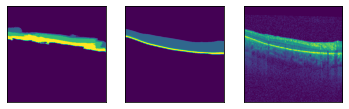

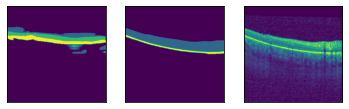

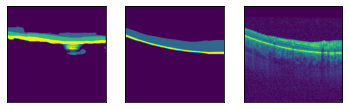

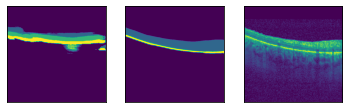

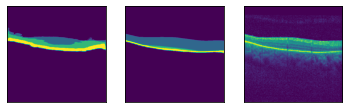

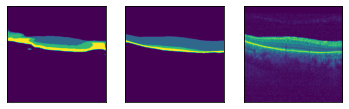

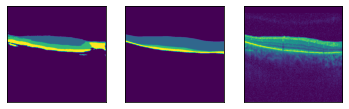

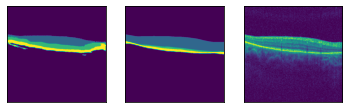

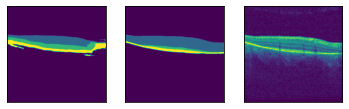

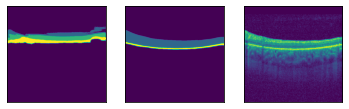

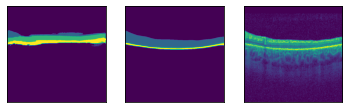

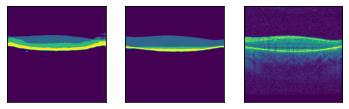

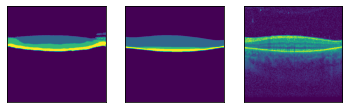

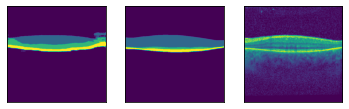

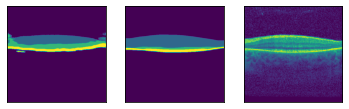

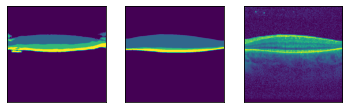

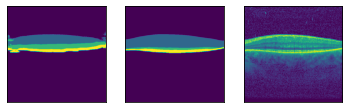

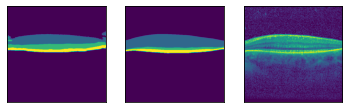

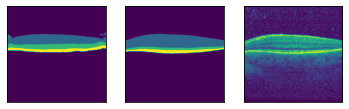

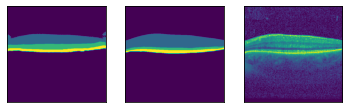

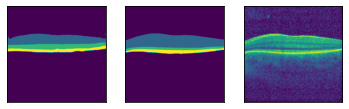

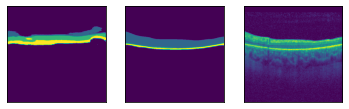

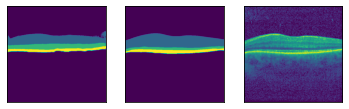

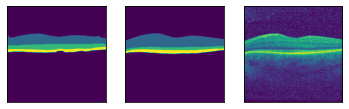

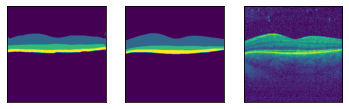

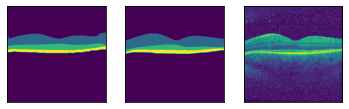

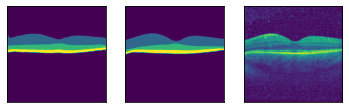

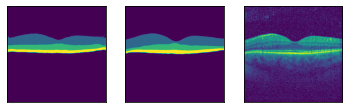

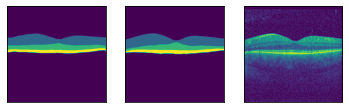

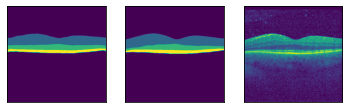

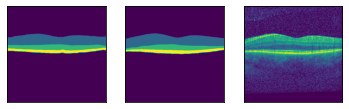

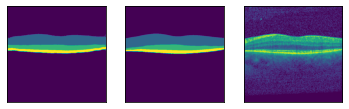

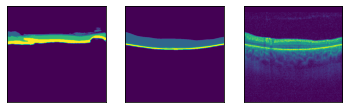

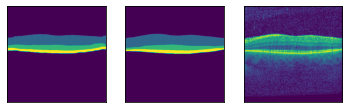

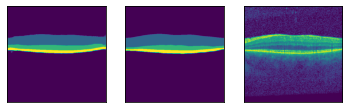

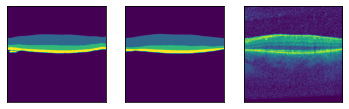

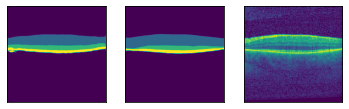

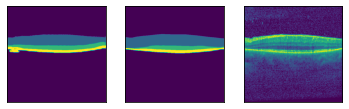

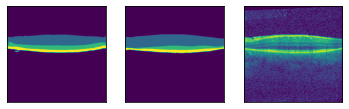

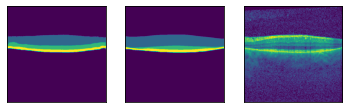

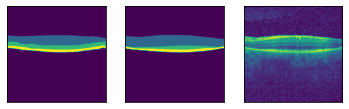

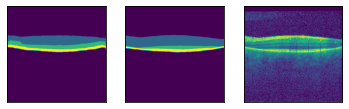

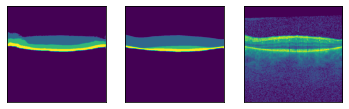

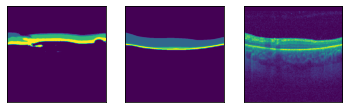

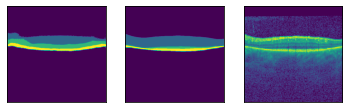

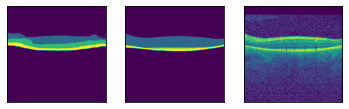

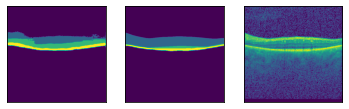

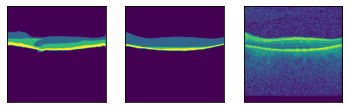

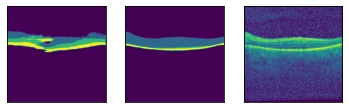

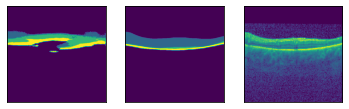

In [18]:
test = test_dataset.shuffle(SHUFFLE_BUFFER_SIZE)
test = test.take(90)

for idx, i in enumerate(test):
    pred = model_new.predict(np.expand_dims(i[0], axis=0))
    pred = np.argmax(pred, axis=-1)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    # fig.suptitle('Test Images: Prediction vs. True')
    ax1.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax2.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax3.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    ax1.imshow(pred[0])
    ax2.imshow(np.argmax(i[1], axis=-1))
    ax3.imshow(i[0])
    plt.savefig(FIG_DIR / f"test_set_{idx}.png", dpi=300)

## Plot results of validation set

In [ ]:
_, val_dataset_viz, _ = datasets_from_maps(train_x_y_map, val_x_y_map, test_x_y_map, batch_size=BATCH_SIZE)
test = val_dataset_viz.unbatch().shuffle(SHUFFLE_BUFFER_SIZE).take(100)

for idx, i in enumerate(test):
    pred = model_new.predict(np.expand_dims(i[0], axis=0))
    pred = np.argmax(pred, axis=-1)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    ax1.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax2.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax3.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    ax1.imshow(pred[0])
    ax2.imshow(np.argmax(i[1], axis=-1))
    ax3.imshow(i[0])
    plt.savefig(FIG_DIR / f"valid_set_{idx}.png", dpi=300)